# Black-Scholes Options Pricer

This notebook walks through the Black-Scholes model from first principles the mathematical assumptions, the formula, and a Python implementation.

---

## 1. The Core Assumption

We assume stock prices follow Geometric Brownian Motion (GBM):

$$S_T = S_0 \cdot \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T} \cdot Z\right)$$

where $Z \sim \mathcal{N}(0, 1)$ is a standard normal random variable.

This implies that log-returns are normally distributed:

$$\ln\left(\frac{S_T}{S_0}\right) \sim \mathcal{N}\left(\left(r - \frac{\sigma^2}{2}\right)T,\ \sigma^2 T\right)$$

The key parameters are:

| Symbol | Meaning |
|--------|---------|
| $S_0$ | Current stock price |
| $K$ | Strike price |
| $T$ | Time to expiration (years) |
| $r$ | Risk-free interest rate |
| $\sigma$ | Volatility (annualized) |


## 2. The Formula

The Black-Scholes price for a European call option is:

$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln\left(\frac{S_0}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

where $N(\cdot)$ is the standard normal CDF and $N'(\cdot)$ its derivative, the PDF.

Interpretation:

- $N(d_2)$ - risk-neutral probability the option expires in the money
- $N(d_1)$ - probability weighted by the stock's contribution to the payoff
- The formula is: *expected stock received* - *expected strike paid*, both discounted and probability-weighted

For a European put:

$$P = K \cdot e^{-rT} \cdot N(-d_2) - S_0 \cdot N(-d_1)$$

The relationship between call and put prices is exact by no-arbitrage (**put-call parity**):

$$C - P = S_0 - K \cdot e^{-rT}$$

In [40]:
import sys
sys.path.append('../src')

import numpy as np
from scipy.stats import norm
from black_scholes import black_scholes_call, black_scholes_put

## 3. Implementation

Our pricer takes five inputs and returns the option price using the closed-form formula above.

In [44]:
# Base parameters
S     = 150    # current stock price
K     = 155    # strike price
T     = 0.5    # 6 months to expiration
r     = 0.05   # 5% risk-free rate
sigma = 0.20   # 20% volatility

call = black_scholes_call(S, K, T, r, sigma)
put  = black_scholes_put(S, K, T, r, sigma)

print(f"Call price: ${call:.2f}")
print(f"Put price: ${put:.2f}")

Call price: $7.92
Put price: $9.09


## 4. Put-Call Parity Verification

The relationship $C - P = S_0 - K \cdot e^{-rT}$ must hold exactly.

In [43]:
lhs = call - put
rhs = S - K * np.exp(-r * T)

print(f"C - P: ${lhs:.4f}")
print(f"S - K*exp(-rT): ${rhs:.4f}")
print(f"Parity holds: {abs(lhs - rhs) < 1e-10}")

C - P: $-1.1730
S - K*exp(-rT): $-1.1730
Parity holds: True


## 5. Sensitivity to Inputs

How does the call price change as we vary each parameter while holding the others fixed?

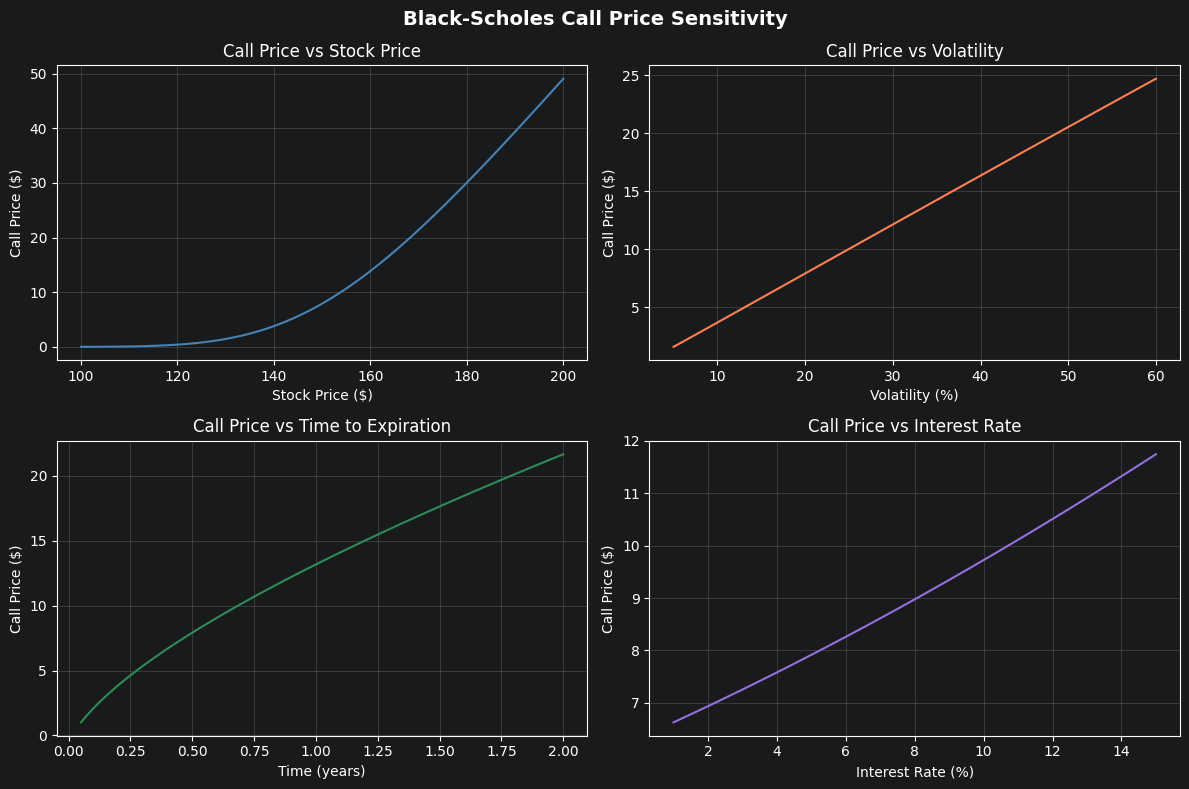

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# vary stock price
s_range = np.linspace(100, 200, 100)
axes[0,0].plot(s_range, [black_scholes_call(s, K, T, r, sigma) for s in s_range], color="steelblue")
axes[0,0].set_title("Call Price vs Stock Price")
axes[0,0].set_xlabel("Stock Price ($)")
axes[0,0].set_ylabel("Call Price ($)")
axes[0,0].grid(alpha=0.3)

# vary volatility
vol_range = np.linspace(0.05, 0.60, 100)
axes[0,1].plot(vol_range * 100, [black_scholes_call(S, K, T, r, v) for v in vol_range], color="coral")
axes[0,1].set_title("Call Price vs Volatility")
axes[0,1].set_xlabel("Volatility (%)")
axes[0,1].set_ylabel("Call Price ($)")
axes[0,1].grid(alpha=0.3)

# vary time to expiration
t_range = np.linspace(0.05, 2.0, 100)
axes[1,0].plot(t_range, [black_scholes_call(S, K, t, r, sigma) for t in t_range], color="seagreen")
axes[1,0].set_title("Call Price vs Time to Expiration")
axes[1,0].set_xlabel("Time (years)")
axes[1,0].set_ylabel("Call Price ($)")
axes[1,0].grid(alpha=0.3)

# vary interest rate
r_range = np.linspace(0.01, 0.15, 100)
axes[1,1].plot(r_range * 100, [black_scholes_call(S, K, T, rr, sigma) for rr in r_range], color="mediumpurple")
axes[1,1].set_title("Call Price vs Interest Rate")
axes[1,1].set_xlabel("Interest Rate (%)")
axes[1,1].set_ylabel("Call Price ($)")
axes[1,1].grid(alpha=0.3)

plt.suptitle("Black-Scholes Call Price Sensitivity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/bs_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- Black-Scholes gives a closed-form price for European options under the assumption of constant volatility and log-normal stock prices
- The formula decomposes into two terms: expected stock received minus expected strike paid, each probability-weighted
- Put-call parity holds exactly by no-arbitrage
- Option prices increase with volatility, time, and stock price (for calls), and decrease as the strike moves further out of the money